In [1]:
# import the functions needed. Pulled in the 9 csv files
import pandas as pd
import glob

csv_files = glob.glob('data/*.csv')

# List to hold dataframes
dataframes = []

# Loop through each CSV file and read them using the correct encoding
for file in csv_files:
    try:
        # Try reading the CSV file with a common encoding 
        df = pd.read_csv(file, encoding='latin1')  # found that the latin1 works for all of them
        dataframes.append(df)
        print(f"Successfully loaded: {file}")
    except UnicodeDecodeError:
        print(f"Encoding error while reading: {file}")
        continue

# print(dataframes[5])


Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\AllstarFull.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\AwardsPlayers.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\AwardsSharePlayers.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\Batting.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\Fielding.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\HallOfFame.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\People.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\Pitching.csv
Successfully loaded: C:\Users\jerem\OneDrive\Desktop\New folder\Predictive Analytics\Excel_files\Teams.

In [3]:

# Select the specific dataframe. This is the players inducted data
df_main_hall = dataframes[5]

# Check for missing or invalid columns before filtering
required_columns = ['yearid', 'inducted', 'votedBy']


# Ensure that all required columns exist in the dataframe
missing_columns = [col for col in required_columns if col not in df_main_hall.columns]
if missing_columns:
    print(f"Missing required columns: {', '.join(missing_columns)}")
else:
    # Players that were inducted into the hall of fame and by the BBWAA
    df_main_hall = df_main_hall[
      (df_main_hall['inducted'] == 'Y') &
      (df_main_hall['votedBy'] == 'BBWAA')
    ]
    
   # print(df_main_hall.head())

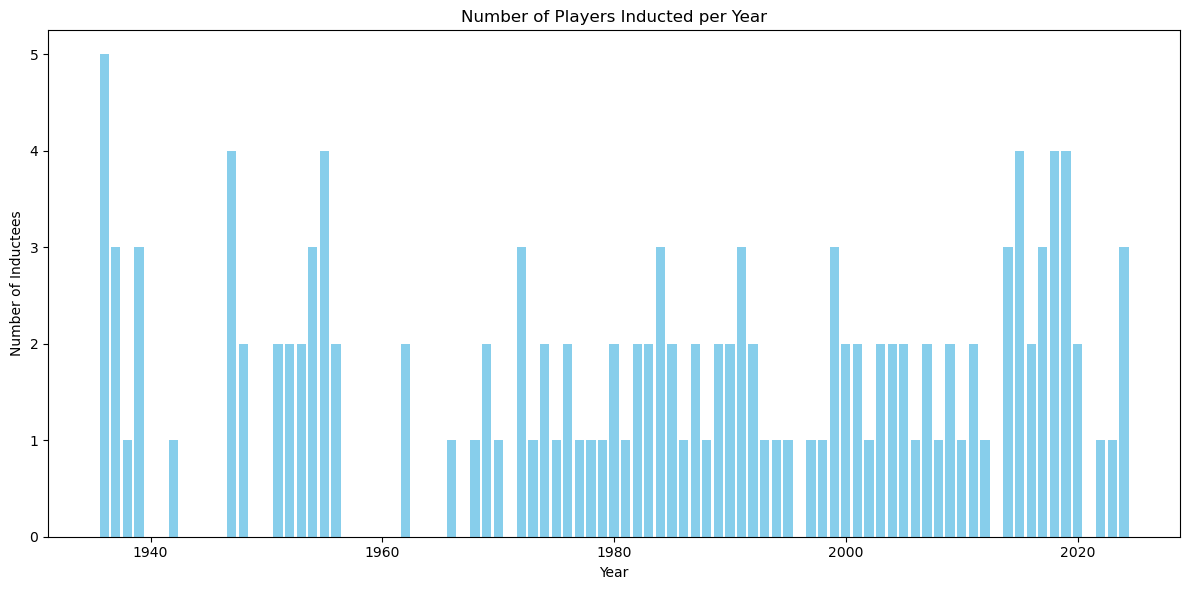

In [79]:


import matplotlib.pyplot as plt

# Groups inductees by year
inducted_per_year = df_main_hall.groupby('yearid').size()

# Plots the graph
plt.figure(figsize=(12, 6))
plt.bar(inducted_per_year.index, inducted_per_year.values, color='skyblue')
plt.title('Number of Players Inducted per Year')
plt.xlabel('Year')
plt.ylabel('Number of Inductees')
plt.tight_layout()
plt.show()

In [7]:

# Pulling in dataframe 5
df_hof_all = dataframes[5]

# Making sure year is a number and puts in NaN for missing values
df_hof_all['yearid'] = pd.to_numeric(df_hof_all['yearid'], errors='coerce')

# Gets those from 1990 on voted on by the BBWAA and only players in the data
df_hof_filtered = df_hof_all[
    (df_hof_all['votedBy'].str.upper() == 'BBWAA') &
    (df_hof_all['category'].str.lower() == 'player')
     ]
#print(df_hof_filtered.head())

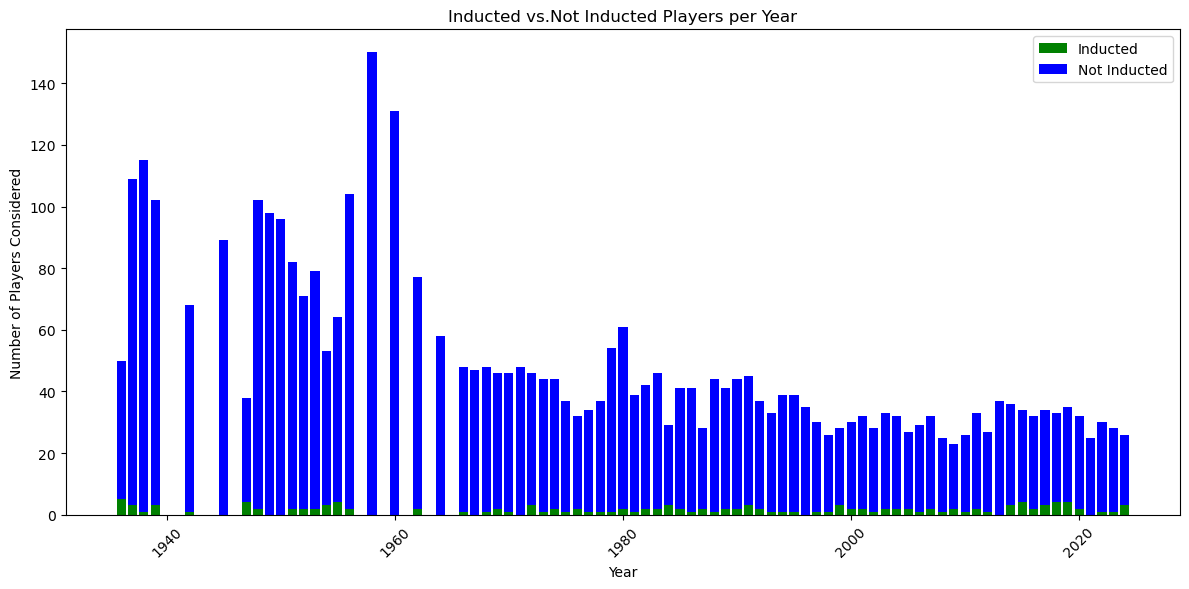

In [11]:

# Grouping by year and if inducted
yearly_counts = df_hof_filtered.groupby(['yearid', 'inducted']).size().unstack(fill_value=0)

# If inducted Y and N for not Inducted
if 'Y' in yearly_counts.columns and 'N' in yearly_counts.columns:
    yearly_counts = yearly_counts[['Y','N']]

# Stacking the Y and N per year with coloring each
plt.figure(figsize=(12, 6))
plt.bar(yearly_counts.index, yearly_counts['Y'], label='Inducted', color='green')
plt.bar(yearly_counts.index, yearly_counts['N'],
        bottom=yearly_counts['Y'], label='Not Inducted', color='blue')

plt.title('Inducted vs.Not Inducted Players per Year')
plt.xlabel('Year')
plt.ylabel('Number of Players Considered')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

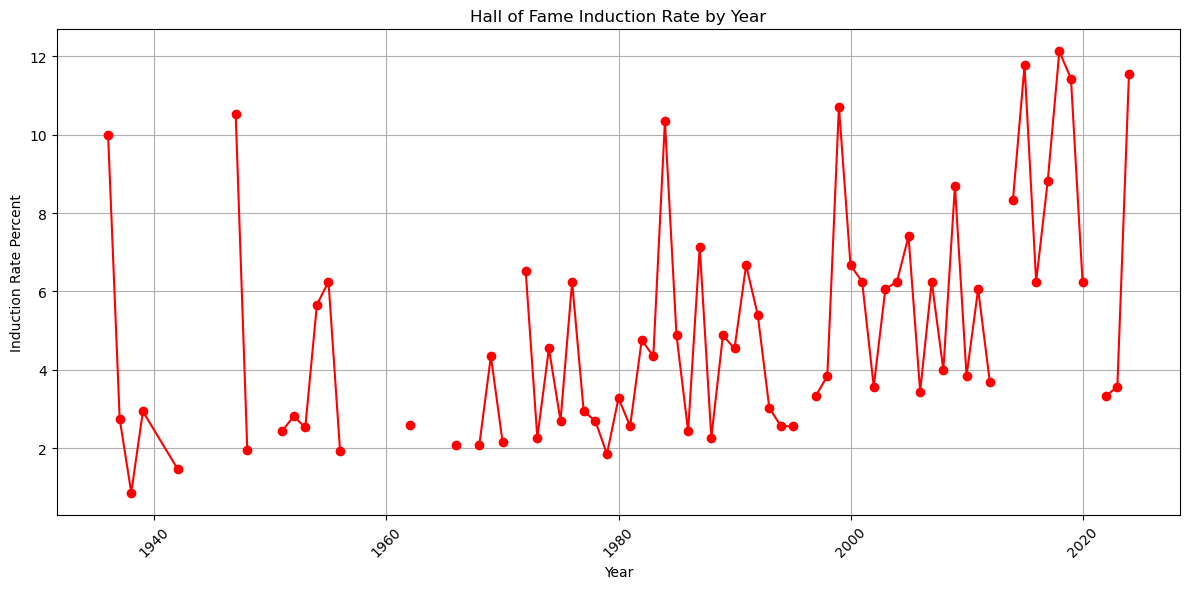

In [13]:

# Gets the total per year and the total inducted
yearly_totals = df_hof_filtered.groupby('yearid').size()
yearly_inducted = df_hof_filtered[df_hof_filtered['inducted'] == 'Y'].groupby('yearid').size()

# Finds the induction rate per year
induction_rate = (yearly_inducted / yearly_totals) * 100

# Plots the graph of the induction rate per year
plt.figure(figsize=(12, 6))
plt.plot(induction_rate.index, induction_rate.values, marker='o', linestyle='-', color='red')

plt.title('Hall of Fame Induction Rate by Year')
plt.xlabel('Year')
plt.ylabel('Induction Rate Percent')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:

# Select the specific dataframe. This is the players voted on for the Hall of Fame
df_main_voted_hall = dataframes[5]

# Check for missing or invalid columns before filtering
required_columns = ['yearid', 'inducted', 'votedBy']


# Ensure that all required columns exist in the dataframe
missing_columns = [col for col in required_columns if col not in df_main_voted_hall.columns]
if missing_columns:
    print(f"Missing required columns: {', '.join(missing_columns)}")
else:
    #  This is the players voted on for the Hall of Fame
    df_main_voted_hall = df_main_voted_hall[
      (df_main_voted_hall['category'].str.lower() == 'player')
    ]
    
   # print(df_main_voted_hall.head())

In [11]:


import pandas as pd
# Going to combine the data from the players in the hall data
# with that of their personal info. Only getting the fields I need from each dataframe
columns_to_keep_hall = ['playerID', 'yearid', 'votedBy', 'inducted', 'category']
columns_to_keep_people = ['playerID', 'nameFirst', 'nameLast']

merged_df_hall_ppl = pd.merge(df_main_voted_hall[columns_to_keep_hall],
                              dataframes[6][columns_to_keep_people],
                              on='playerID', how='left')

# merged_df_hall_ppl.head()


In [13]:


sorted_df = merged_df_hall_ppl.copy()

# Add a helper column for prioritizing inducted players
sorted_df['inducted_flag'] = (sorted_df['inducted'] == 'Y').astype(int)

# Sort by playerID, inducted_flag, and yearid
sorted_df = sorted_df.sort_values(by=['playerID', 'inducted_flag', 'yearid'], ascending=[True, False, False])

# Drop duplicates, keeping the first record per player
final_df = sorted_df.drop_duplicates(subset='playerID', keep='first')

# Drop the helper column
final_df = final_df.drop(columns='inducted_flag')

# View result
# final_df.head(10)

In [15]:
# Bring in the all star data
all_star_df = dataframes[0]

# Sum up how many all star appearances each player had
all_star_counts = all_star_df.groupby('playerID').size().reset_index(name='all_star_appearances')

print(all_star_counts.head())

    playerID  all_star_appearances
0  aaronha01                    24
1   aasedo01                     1
2  abreubo01                     2
3  abreujo02                     3
4  acunaro01                     5


In [17]:
# Bring in the awards data
awards_df = dataframes[1]

# Had to update the silver slugger award name since there were 2 different spellings
# Group by each player and awards for each to see how many of each they had
awards_df['awardID'] = awards_df['awardID'].replace({'SIlver Slugger': 'Silver Slugger'})
award_breakdown = awards_df.groupby(['playerID', 'awardID']).size().unstack(fill_value=0)

# print(award_breakdown.head())

In [21]:
# creating a copy of the final_df to make sure I don't change it
model_df = final_df.copy()

# Adding the all star appearances to the main data and if they don't have any, setting to 0
model_df = pd.merge(model_df, all_star_counts, on='playerID', how='left')
model_df['all_star_appearances'] = model_df['all_star_appearances'].fillna(0).astype(int)

# Adding the awards to the dataset and if they never received an awards, setting it to 0
model_df = pd.merge(model_df, award_breakdown, on='playerID', how='left')
model_df[award_breakdown.columns] = model_df[award_breakdown.columns].fillna(0).astype(int)

# print(model_df.columns.tolist())
# print(model_df.head())

In [23]:
# Getting the batting and pitching stats that I want to look at
batting_cols = ['playerID','yearID', 'teamID', 'AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB']
pitching_cols = ['playerID', 'yearID', 'teamID',  'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB',	'SO', 'ERA']

# pulling the columns from those datasets
batting_df = dataframes[3][batting_cols]
pitching_df = dataframes[7][pitching_cols]

# combining the pitching and batting stats for each player for the same year and team
batting_pitching_merged = pd.merge(
    batting_df,
    pitching_df,
    on=['playerID', 'yearID', 'teamID'],
    how='outer'
)

# print(batting_pitching_merged.head())

In [25]:

# Use the correct fielding data (dataframes[4])
df_fielding_pos = dataframes[4][['playerID', 'POS', 'G']].copy()

# Total games played by each player at each position
df_pos_totals = df_fielding_pos.groupby(['playerID', 'POS'], as_index=False)['G'].sum()

# Sort to get the position with the most games played
df_pos_sorted = df_pos_totals.sort_values(['playerID', 'G'], ascending=[True, False])

# Keep only the top position per player
df_primary_career_pos = df_pos_sorted.drop_duplicates(subset=['playerID'])[['playerID', 'POS']]

# Rename column for clarity
df_primary_career_pos = df_primary_career_pos.rename(columns={'POS': 'career_primary_POS'})

print(df_primary_career_pos.head())

     playerID career_primary_POS
0   aardsda01                  P
4   aaronha01                 OF
5   aaronto01                 1B
9    aasedo01                  P
10   abadan01                 1B


In [27]:
# Getting the columns for fielding stats
columns_to_keep_fielding = ['playerID', 'yearID', 'teamID', 'POS', 'InnOuts', 'PO', 'A', 'E']

# creating a fielding dataset
fielding_df = dataframes[4][columns_to_keep_fielding].copy()

# Group by player, year and team for the statistics
fielding_summary = fielding_df.groupby(['playerID', 'yearID', 'teamID'], as_index=False)[['InnOuts', 'PO', 'A', 'E']].sum()

# print("Standalone fielding summary:")
# print(fielding_summary.head())

In [31]:
# Bringing in the fielding data and creating a main dataset 
full_stats_df = pd.merge(
    batting_pitching_merged,
    fielding_summary,
    on=['playerID', 'yearID', 'teamID'],
    how='outer'
)

# print("combined batting, pitching, and fielding:")
# print(full_stats_df.head())

In [35]:

import pandas as pd

# Define the fields you want to sum
fields_to_sum = [
    'AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB',
    'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO',
    'InnOuts', 'PO', 'A', 'E'
    # ERA excluded here
]

# Sum selected fields for each player
career_stats_df = (
    full_stats_df
    .groupby('playerID', as_index=False)[fields_to_sum]
    .sum(numeric_only=True)
)

# Batting Average = H / AB
career_stats_df['batting_avg'] = career_stats_df['H'] / career_stats_df['AB']
career_stats_df['batting_avg'] = career_stats_df['batting_avg'].fillna(0)

# Primary Team = team they appeared for most
team_counts = (
    full_stats_df
    .groupby(['playerID', 'teamID'])
    .size()
    .reset_index(name='appearances')
)
# keeps the team they played for the most
most_common_team = (
    team_counts
    .sort_values(['playerID', 'appearances'], ascending=[True, False])
    .drop_duplicates('playerID')[['playerID', 'teamID']]
    .rename(columns={'teamID': 'primary_team'})
)

# Adds the primary team
career_stats_df = pd.merge(career_stats_df, most_common_team, on='playerID', how='left')

# Weighted ERA
# Convert ERA to a weighted version using innings pitched
full_stats_df['IP'] = full_stats_df['InnOuts'] / 3
full_stats_df['ERA_weighted'] = full_stats_df['ERA'] * full_stats_df['IP']

# Sum ERA*IP and total IP per player
era_weighted_df = (
    full_stats_df.groupby('playerID', as_index=False)[['ERA_weighted', 'IP']]
    .sum()
)

# weighted career ERA
era_weighted_df['career_ERA'] = era_weighted_df['ERA_weighted'] / era_weighted_df['IP']
era_weighted_df = era_weighted_df[['playerID', 'career_ERA']]

# Merge weighted ERA into final career stats
career_stats_df = pd.merge(career_stats_df, era_weighted_df, on='playerID', how='left')

#print(career_stats_df.head())

In [37]:

# check for dups on playerID
duplicate_ids = career_stats_df['playerID'][career_stats_df['playerID'].duplicated()]
print("Duplicate playerIDs found:")
print(duplicate_ids.unique())

Duplicate playerIDs found:
[]


In [41]:

# Merge model_df with career stats
model_with_stats = pd.merge(
    model_df,
    career_stats_df,
    on='playerID',
    how='left'
)

# Merge in primary position
final_model_df = pd.merge(
    model_with_stats,
    df_primary_career_pos.rename(columns={'POS': 'primary_position'}),
    on='playerID',
    how='left'
)

# print(final_model_df.head())

In [43]:

# check for dups on playerID
duplicate_ids = final_model_df['playerID'][final_model_df['playerID'].duplicated()]
print("Duplicate playerIDs found:")
print(duplicate_ids.unique())

Duplicate playerIDs found:
[]


In [49]:
# Doing this for to get the same stats for those that were not voted on or have not had a chance yet
# Since did this step by step before tried to do it more eifficent for these players

# Bringing in the stats data
batting_df = dataframes[3]    # Batting
pitching_df = dataframes[7]   # Pitching
fielding_df = dataframes[4]   # Fielding

# Batting stats that I want to sum up
batting_cols = ['playerID', 'AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB']
career_batting = (
    batting_df
    .groupby('playerID', as_index=False)[batting_cols[1:]]
    .sum(numeric_only=True)
)
# Getting batting average like before
career_batting['batting_avg'] = career_batting['H'] / career_batting['AB']
career_batting['batting_avg'] = career_batting['batting_avg'].fillna(0)

# pitching stats that I want to sum up and doing the weighted era
pitching_df = pitching_df.copy()
pitching_df['IP'] = pitching_df.get('IPouts', 0) / 3  
pitching_df['ERA_weighted'] = pitching_df['ERA'] * pitching_df['IP']

# Summing up the pitching stats
career_pitching = (
    pitching_df
    .groupby('playerID', as_index=False)[
        ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'ERA_weighted', 'IP']
    ]
    .sum(numeric_only=True)
)
career_pitching['career_ERA'] = career_pitching['ERA_weighted'] / career_pitching['IP']
career_pitching = career_pitching.drop(columns=['ERA_weighted', 'IP'])

# fielding stats needed to sum
fielding_cols = ['playerID', 'InnOuts', 'PO', 'A', 'E']
career_fielding = (
    fielding_df
    .groupby('playerID', as_index=False)[fielding_cols[1:]]
    .sum(numeric_only=True)
)

# Finding the primary position for the other players
fielding_pos_df = fielding_df[['playerID', 'POS', 'G']].copy()
pos_totals = (
    fielding_pos_df
    .groupby(['playerID', 'POS'], as_index=False)['G']
    .sum()
)
pos_sorted = pos_totals.sort_values(['playerID', 'G'], ascending=[True, False])
primary_pos_df = pos_sorted.drop_duplicates(subset='playerID')[['playerID', 'POS']]
primary_pos_df = primary_pos_df.rename(columns={'POS': 'career_primary_POS'})

# Bringing it all together to one dataset
career_all_stats = (
    career_batting
    .merge(career_pitching, on='playerID', how='outer')
    .merge(career_fielding, on='playerID', how='outer')
    .merge(primary_pos_df, on='playerID', how='left')
)

# Rearrange columns to make more sense
cols_order = ['playerID', 'career_primary_POS', 'AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB',
              'batting_avg', 'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA',
              'InnOuts', 'PO', 'A', 'E']
career_all_stats = career_all_stats[cols_order]

# print(career_all_stats.head())

In [51]:
# check for dups on playerID
duplicate_ids = career_all_stats['playerID'][career_all_stats['playerID'].duplicated()]
print("Duplicate playerIDs found:")
print(duplicate_ids.unique())

Duplicate playerIDs found:
[]


In [53]:
# Need to break out those that were not in the hall of fame dataset before

hof_voted_df = dataframes[5]
# Includes those that were voted on for the hall, since those were done before
voted_player_ids = set(hof_voted_df['playerID'].unique())

# Dataset of all players
all_player_ids = set(career_stats_df['playerID'].unique())

# To get those that were never voted on for the hall of fame
never_voted_player_ids = all_player_ids - voted_player_ids

# Filters the career_stats_df to be those that were never voted on
non_hof_career_stats = career_stats_df[career_stats_df['playerID'].isin(never_voted_player_ids)].copy()

# print(non_hof_career_stats.head())

In [57]:
# Need to do the same for the awards and all star appearances for the non-voted yet as done for the hall of fame voted players
# Fix Silver Slugger typo
awards_df = dataframes[1]
awards_df['awardID'] = awards_df['awardID'].replace({'SIlver Slugger': 'Silver Slugger'})

# Filter and pivot awards
non_hof_awards = awards_df[awards_df['playerID'].isin(never_voted_player_ids)]
award_counts = non_hof_awards.groupby(['playerID', 'awardID']).size().unstack(fill_value=0)

# All-star appearances sum up per player
all_star_df = dataframes[0]
non_hof_all_star = all_star_df[all_star_df['playerID'].isin(never_voted_player_ids)]
all_star_counts = non_hof_all_star.groupby('playerID').size().reset_index(name='all_star_appearances')

# Merge awards and all-star appearances into the career stats
non_hof_model_df = non_hof_career_stats.merge(
    award_counts,
    left_on='playerID',
    right_index=True,
    how='left'
).merge(
    all_star_counts,
    on='playerID',
    how='left'
)

# if any blank fields put it to 0
non_hof_model_df = non_hof_model_df.fillna({
    **{col: 0 for col in award_counts.columns},
    'all_star_appearances': 0
})

# print("Final non-HOF model dataset (with awards and all-star counts):")
# print(non_hof_model_df.head())

In [63]:
# Assign primary position from fielding_df
fielding_pos_df = fielding_df[['playerID', 'POS', 'G']].copy()
pos_totals = (
    fielding_pos_df
    .groupby(['playerID', 'POS'], as_index=False)['G']
    .sum()
)
pos_sorted = pos_totals.sort_values(['playerID', 'G'], ascending=[True, False])
primary_pos_df = pos_sorted.drop_duplicates(subset='playerID')[['playerID', 'POS']]
primary_pos_df = primary_pos_df.rename(columns={'POS': 'career_primary_POS'})
primary_pos_df['career_primary_POS'] = primary_pos_df['career_primary_POS'].str.upper()

# Merge primary position into non-HOF dataset
non_hof_model_df = non_hof_model_df.copy()
non_hof_model_df['playerID'] = non_hof_model_df['playerID'].astype(str)
non_hof_model_df = non_hof_model_df.merge(primary_pos_df, on='playerID', how='left')

# Need to get the name for the non-voted players
people_df = dataframes[6][['playerID', 'nameFirst', 'nameLast']]

# Merge names into the non-HOF model dataset
non_hof_model_df_named = non_hof_model_df.merge(
    people_df,
    on='playerID',
    how='left'
)

# Rearrange columns for easier reading
cols = ['playerID', 'nameFirst', 'nameLast', 'career_primary_POS'] + [
    col for col in non_hof_model_df_named.columns
    if col not in ['playerID', 'nameFirst', 'nameLast', 'career_primary_POS']
]
non_hof_model_df_named = non_hof_model_df_named[cols]

# print("Non-HOF dataset with player names and primary position:")
# print(non_hof_model_df_named.head())

In [65]:
# Make a copy of the original final_model_df
hof_model_df = final_model_df.copy()

# Create the hof_inducted column based on inducted
hof_model_df['hof_inducted'] = hof_model_df['inducted'].apply(lambda x: 1 if x == 'Y' else 0)

# Ensure all award columns exist
for col in award_counts.columns:
    if col not in hof_model_df.columns:
        hof_model_df[col] = 0

# Fill missing values in award columns if blank
hof_model_df[award_counts.columns] = hof_model_df[award_counts.columns].fillna(0)

# Ensure all_star_appearances exists and has no missing values
hof_model_df['all_star_appearances'] = hof_model_df.get('all_star_appearances', 0).fillna(0)

# Set hof_inducted = 0 for all non-HOF players
non_hof_model_df_named['hof_inducted'] = 0

# Add any missing columns to non-HOF df to match HOF df
for col in hof_model_df.columns:
    if col not in non_hof_model_df_named.columns:
        non_hof_model_df_named[col] = 0

# reorder columns to match before
non_hof_model_df_named = non_hof_model_df_named[hof_model_df.columns]

# Combine both datasets
combined_df = pd.concat([hof_model_df, non_hof_model_df_named], ignore_index=True, sort=False)

# Shuffle combined dataset for modeling
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

#print("Combined dataset ready for modeling:")
#print(combined_df.head())

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Copy your full combined dataset
df = combined_df.copy()

# Ensure hof_inducted is numeric: 1 if inducted 'Y', else 0
df['hof_inducted'] = df['inducted'].fillna('N').apply(lambda x: 1 if x == 'Y' else 0)

# Rename since ran into a problem with primary position
if 'career_primary_POS' in df.columns and 'PrimaryPosition' not in df.columns:
    df.rename(columns={'career_primary_POS': 'PrimaryPosition'}, inplace=True)

# Columns to drop before modeling
drop_cols_common = [
    'playerID', 'nameFirst', 'nameLast', 'yearid', 'votedBy', 'category',
    'primary_team', 'PrimaryPosition', 'inducted'
]

# Shared awards used for all positions
shared_awards = [
    'Most Valuable Player',
    'All-Star Game MVP',
    'World Series MVP',
    'Rookie of the Year',
    'Lou Gehrig Memorial Award',
    'Babe Ruth Award',
    'TSN Player of the Year',
    'TSN Major League Player of the Year',
    'TSN Guide MVP',
    'TSN All-Star',
    'Baseball Magazine All-Star',
    'Gold Glove',
    'Platinum Glove',
    'NLCS MVP',
    'ALCS MVP',
    'Roberto Clemente Award',
    'Comeback Player of the Year',
    'Branch Rickey Award',
    'Hutch Award',
    'all_star_appearances'
]

# Batting stats for position players
batting_stats = ['AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB', 'batting_avg']

# Pitching stats for pitchers
pitching_stats = ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA']

# Fielding stats for all
fielding_stats = ['InnOuts', 'PO', 'A', 'E']

# Hitter-only awards
hitter_only_awards = [
    'Silver Slugger',
    'Hank Aaron Award',
    'Outstanding DH Award',
    'Branch Rickey Award',
    'Triple Crown'
]

# Pitcher-only awards
pitcher_only_awards = [
    'Cy Young Award',
    'Reliever of the Year Award',
    'Pitching Triple Crown',
    'TSN Pitcher of the Year',
    'TSN Fireman of the Year',
    'TSN Reliever of the Year'
]

# Positions to model
positions = ['P', 'C', '1B', '2B', '3B', 'SS', 'OF']

for pos in positions:
    print(f"\n=== Position: {pos} ===")

    # Filter dataset for players at this primary position
    df_pos = df[df['PrimaryPosition'] == pos].copy()

    # Skip positions with too few players or no class variation
    if df_pos.shape[0] < 20 or df_pos['hof_inducted'].nunique() < 2:
        print("Not enough data or class variation — skipping.")
        continue

    # Select stats based on position
    if pos == 'P':
        features = pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
    else:
        features = batting_stats + fielding_stats + shared_awards + hitter_only_awards

    # Ensure all stats exist in the dataframe and add missing as zeros
    for feat in features:
        if feat not in df_pos.columns:
            df_pos[feat] = 0

    # Drop columns that aren’t features or target
    df_pos.drop(columns=drop_cols_common, errors='ignore', inplace=True)

    # Define stats matrix X and target vector y
    X = df_pos[features].fillna(0)
    y = df_pos['hof_inducted']

    # Scale stats
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split into train and test sets with stratified sampling on target
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )

    # Initialize logistic regression model with class balancing
    model = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced')
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Print classification report and ROC AUC score
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))


=== Position: P ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1924
           1       0.36      1.00      0.52        16

    accuracy                           0.99      1940
   macro avg       0.68      0.99      0.76      1940
weighted avg       0.99      0.99      0.99      1940

AUC-ROC Score: 0.9973037941787942

=== Position: C ===
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       386
           1       0.33      0.50      0.40         4

    accuracy                           0.98       390
   macro avg       0.66      0.74      0.70       390
weighted avg       0.99      0.98      0.99       390

AUC-ROC Score: 0.9863989637305699

=== Position: 1B ===
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       222
           1       0.38      1.00   

In [83]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# Make a fresh copy of the modeling dataset
df = combined_df.copy()

# Create target variable
df['hof_inducted'] = df['inducted'].fillna('N').apply(lambda x: 1 if x == 'Y' else 0)

# Rename column to be safe
if 'career_primary_POS' in df.columns and 'PrimaryPosition' not in df.columns:
    df.rename(columns={'career_primary_POS': 'PrimaryPosition'}, inplace=True)

# Drop columns not needed in modeling
drop_cols_common = [
    'playerID', 'nameFirst', 'nameLast', 'yearid', 'votedBy', 'category',
    'primary_team', 'PrimaryPosition', 'inducted'
]

# shared and specific features
shared_awards = [
    'Most Valuable Player',
    'All-Star Game MVP',
    'World Series MVP',
    'Rookie of the Year',
    'Lou Gehrig Memorial Award',
    'Babe Ruth Award',
    'TSN Player of the Year',
    'TSN Major League Player of the Year',
    'TSN Guide MVP',
    'TSN All-Star',
    'Baseball Magazine All-Star',
    'Gold Glove',
    'Platinum Glove',
    'All-Star Game MVP',
    'NLCS MVP',
    'ALCS MVP',
    'Roberto Clemente Award',
    'Comeback Player of the Year',
    'Branch Rickey Award',
    'Hutch Award',
    'all_star_appearances'
]

# Position-specific stats
batting_stats = ['AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB', 'batting_avg']
pitching_stats = ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA']
fielding_stats = ['InnOuts', 'PO', 'A', 'E']

# Hitter-only awards
hitter_only_awards = [
    'Silver Slugger',
    'Hank Aaron Award',
    'Outstanding DH Award',
    'Branch Rickey Award',
    'Triple Crown' 
]

# Pitcher-only awards
pitcher_only_awards = [
  'Cy Young Award',
    'Reliever of the Year Award',
    'Pitching Triple Crown',
    'TSN Pitcher of the Year',
    'TSN Fireman of the Year',
    'TSN Reliever of the Year'
]

positions = ['P', 'C', '1B', '2B', '3B', 'SS', 'OF']



=== RANDOM FOREST PER POSITION WITH PLOTS ===

--- Position: P ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1924
           1       0.86      0.75      0.80        16

    accuracy                           1.00      1940
   macro avg       0.93      0.87      0.90      1940
weighted avg       1.00      1.00      1.00      1940

AUC-ROC Score: 0.9990579521829521


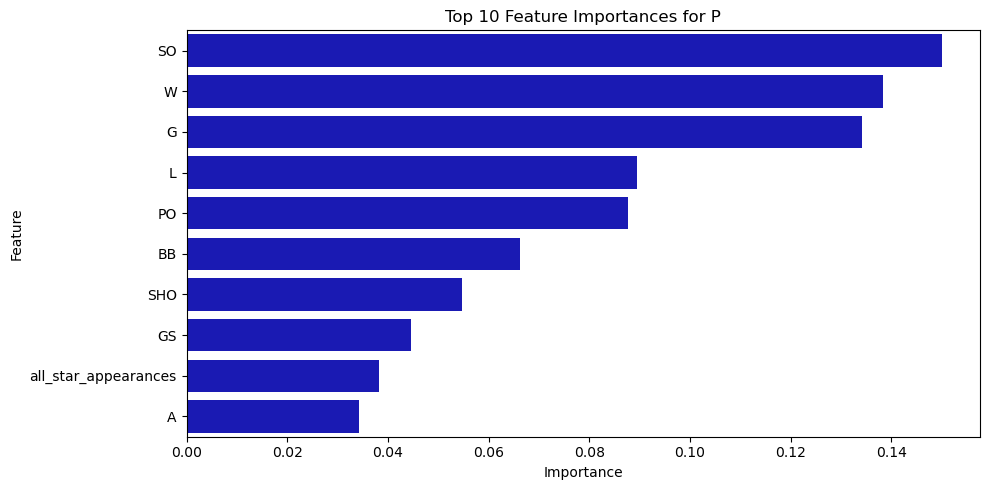

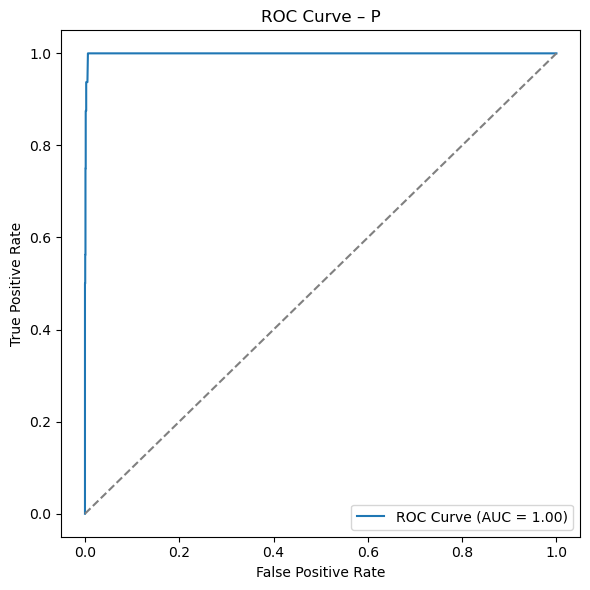


--- Position: C ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       386
           1       0.50      0.25      0.33         4

    accuracy                           0.99       390
   macro avg       0.75      0.62      0.66       390
weighted avg       0.99      0.99      0.99       390

AUC-ROC Score: 0.8694948186528497


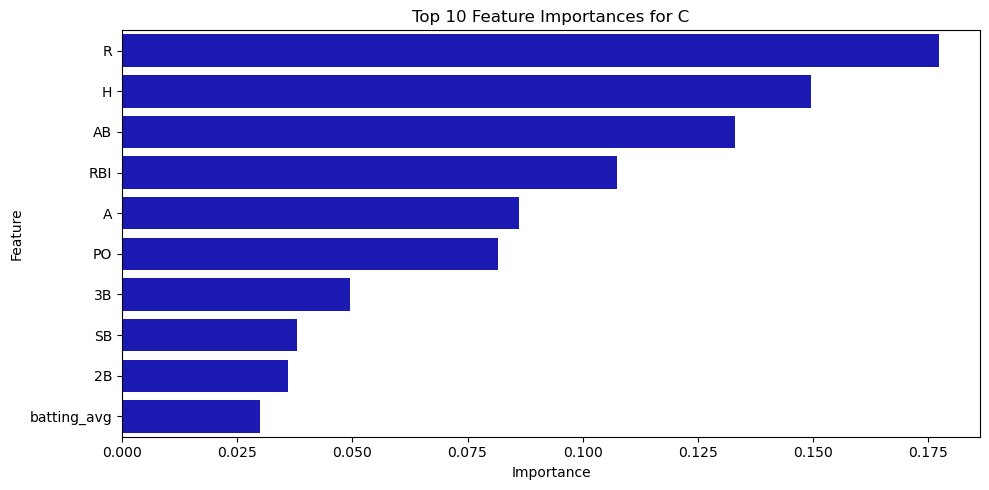

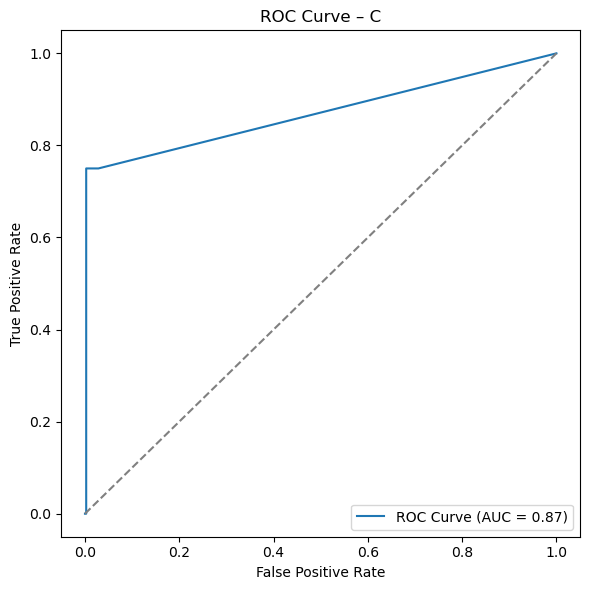


--- Position: 1B ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       222
           1       0.71      0.83      0.77         6

    accuracy                           0.99       228
   macro avg       0.85      0.91      0.88       228
weighted avg       0.99      0.99      0.99       228

AUC-ROC Score: 0.9924924924924925


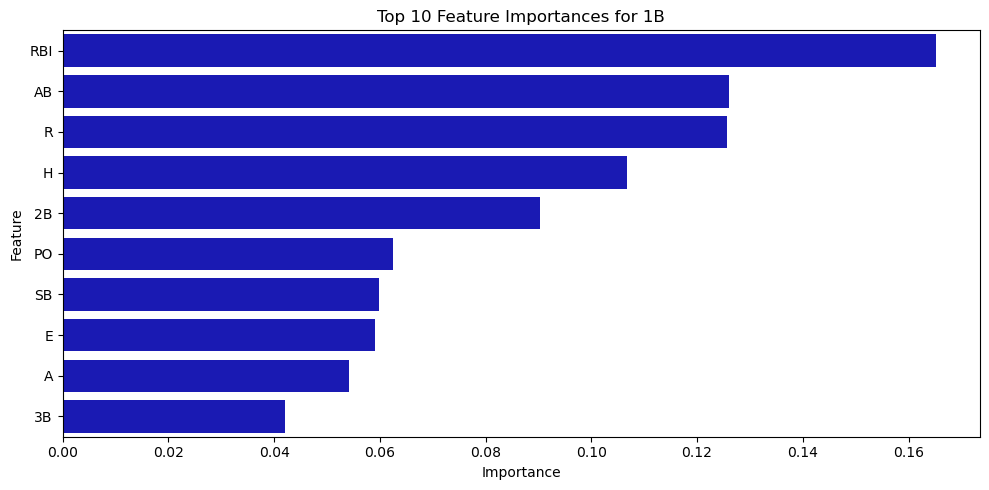

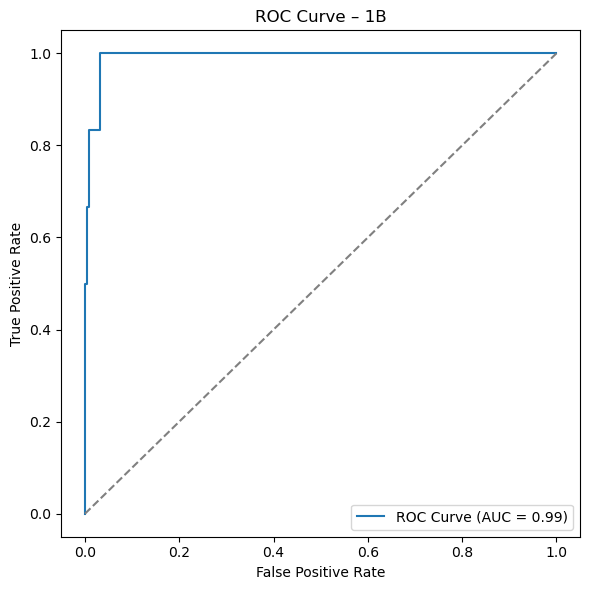


--- Position: 2B ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       254
           1       1.00      0.50      0.67         4

    accuracy                           0.99       258
   macro avg       1.00      0.75      0.83       258
weighted avg       0.99      0.99      0.99       258

AUC-ROC Score: 0.9970472440944882


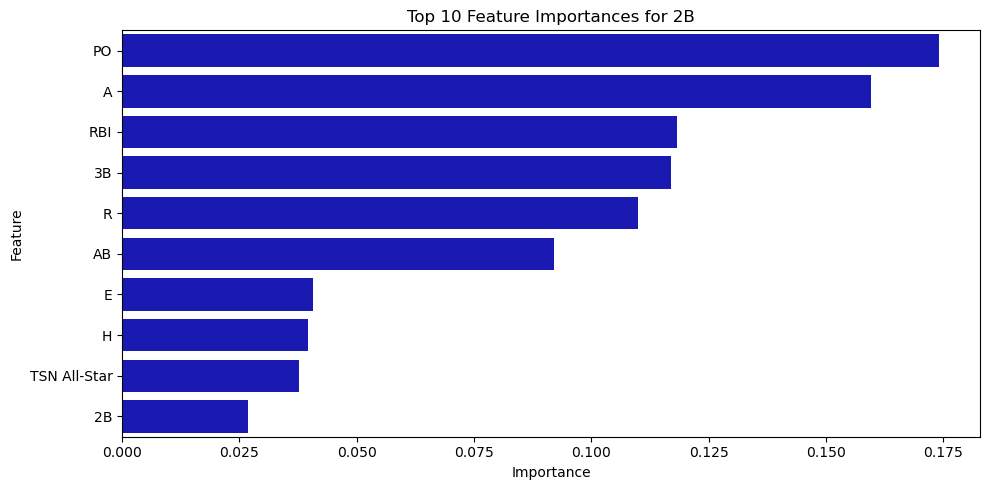

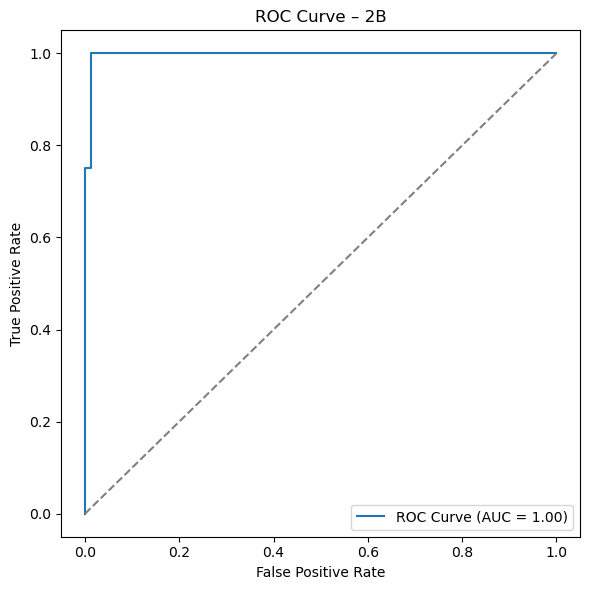


--- Position: 3B ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       233
           1       1.00      0.50      0.67         4

    accuracy                           0.99       237
   macro avg       1.00      0.75      0.83       237
weighted avg       0.99      0.99      0.99       237

AUC-ROC Score: 1.0


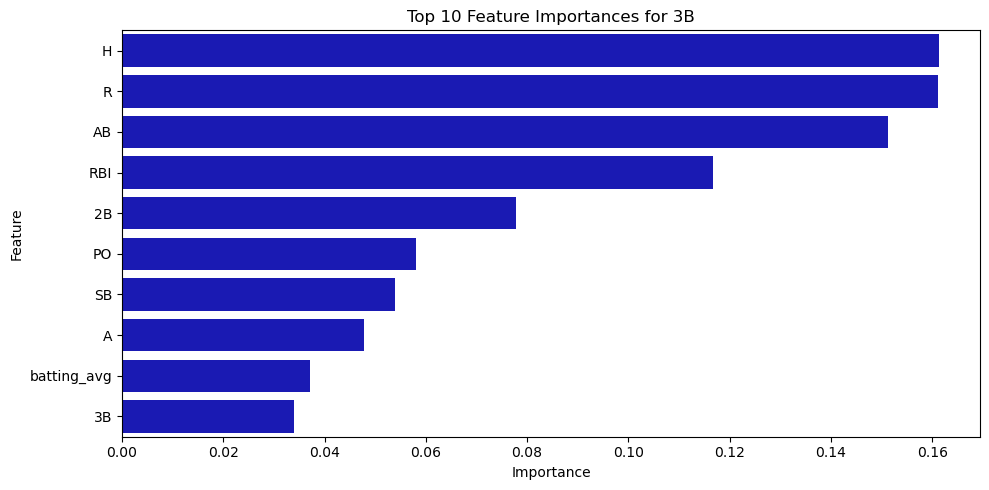

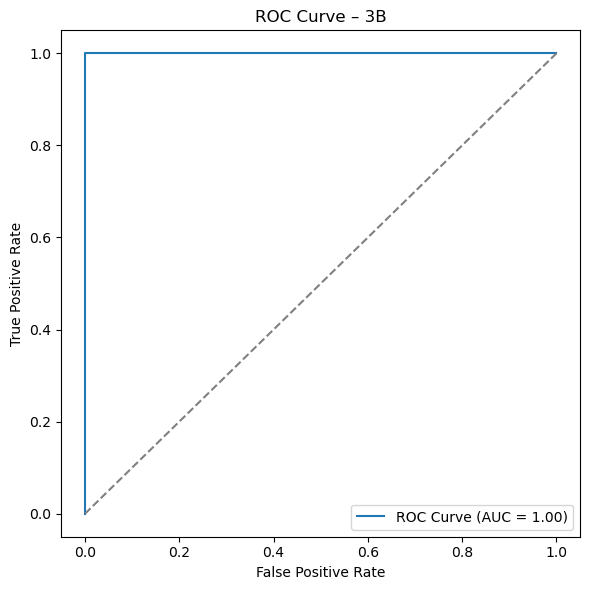


--- Position: SS ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       0.80      0.80      0.80         5

    accuracy                           0.99       233
   macro avg       0.90      0.90      0.90       233
weighted avg       0.99      0.99      0.99       233

AUC-ROC Score: 0.9956140350877193


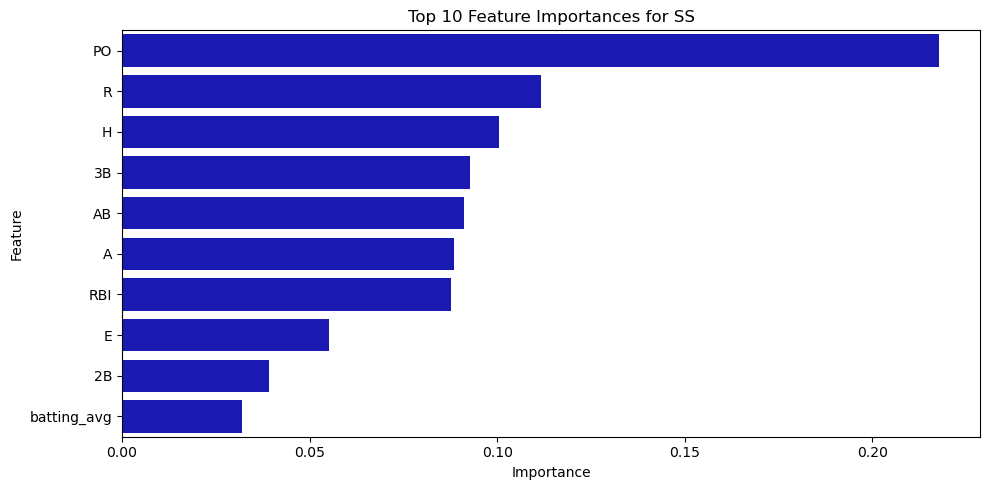

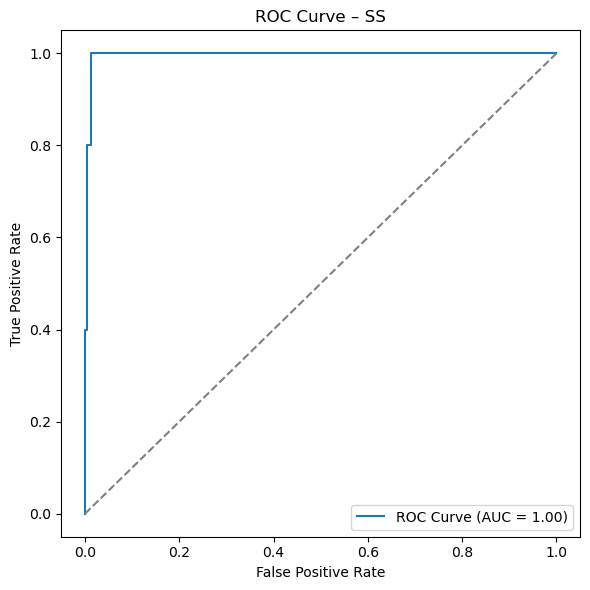


--- Position: OF ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       800
           1       0.71      0.36      0.48        14

    accuracy                           0.99       814
   macro avg       0.85      0.68      0.73       814
weighted avg       0.98      0.99      0.98       814

AUC-ROC Score: 0.995267857142857


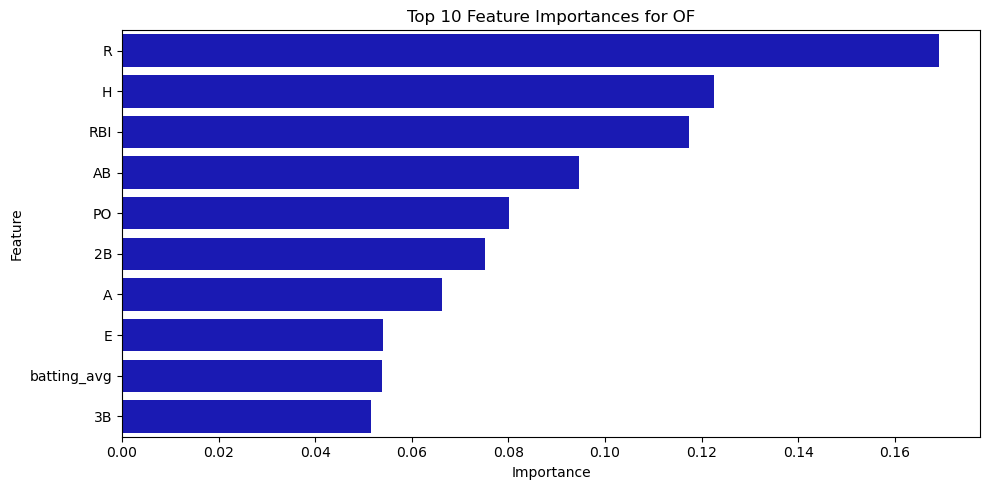

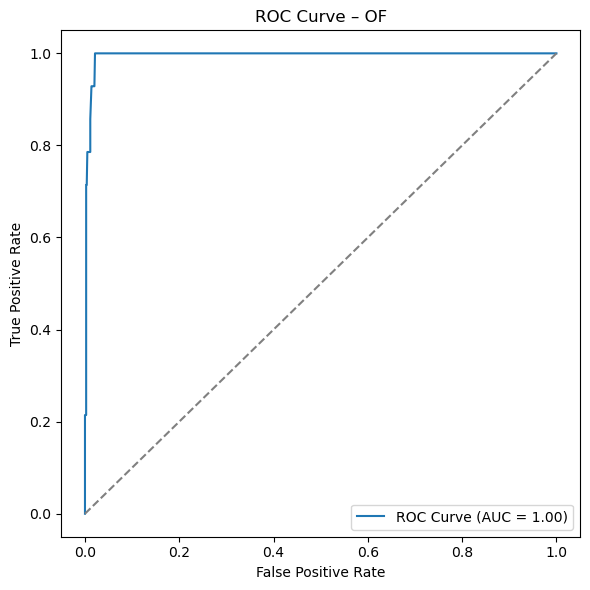

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

print("=== RANDOM FOREST PER POSITION WITH PLOTS ===")

# Goes through each position from above for primary position
for pos in positions:
    print(f"\n--- Position: {pos} ---")

    # Filter dataset for players at this primary position
    df_pos = df[df['PrimaryPosition'] == pos].copy()

    # Skip positions with too few players or no class variation
    if df_pos.shape[0] < 20 or df_pos['hof_inducted'].nunique() < 2:
        print("Skipping due to insufficient data or no class variation.")
        continue

    # Select stats based on position
    if pos == 'P':
        features = pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
    else:
        features = batting_stats + fielding_stats + shared_awards + hitter_only_awards

    # Drop columns that aren’t features or target
    df_pos.drop(columns=drop_cols_common, errors='ignore', inplace=True)

    # Ensure all stats exist in the dataframe and add missing as zeros
    for feat in features:
        if feat not in df_pos.columns:
            df_pos[feat] = 0

    # Define feature matrix X and target vector y
    X = df_pos[features].fillna(0)
    y = df_pos['hof_inducted']

    # Scale stats
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split into train and test sets with stratified sampling on target
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )

    # Initialize Random Forest model with class balancing
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)

    # Predict on test data
    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))

    # Stats importances plot
    importances = rf_model.feature_importances_
    indices = importances.argsort()[::-1]
    top_n = 10

    # Plot the graph
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=importances[indices[:top_n]],
        y=[features[i] for i in indices[:top_n]],
        color='mediumblue'
    )
    plt.title(f"Top {top_n} Feature Importances for {pos}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # ROC Curve plot
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {pos}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [87]:

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

print("=== NEURAL NETWORK PER POSITION ===")
# Goes through each position from above for primary position
for pos in positions:
    print(f"\n--- Position: {pos} ---")

    # Filter dataset for players at this primary position
    df_pos = df[df['PrimaryPosition'] == pos].copy()

    # Skip positions with too few players or no class variation
    if df_pos.shape[0] < 20 or df_pos['hof_inducted'].nunique() < 2:
        print("Skipping due to insufficient data or no class variation.")
        continue

    # Select stats based on position
    if pos == 'P':
        features = pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
    else:
        features = batting_stats + fielding_stats + shared_awards + hitter_only_awards

    # Drop columns that aren’t features or target
    df_pos.drop(columns=drop_cols_common, errors='ignore', inplace=True)

    # Ensure all stats exist in the dataframe and add missing as zeros
    for feat in features:
        if feat not in df_pos.columns:
            df_pos[feat] = 0

    # Define feature matrix X and target vector y
    X = df_pos[features].fillna(0)
    y = df_pos['hof_inducted']

    # Scale stats
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split into train and test sets with stratified sampling on target
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42
    )

    # Initialize Random Forest model with class balancing
    mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=2000, random_state=42)
    mlp.fit(X_train, y_train)

    # Predict on test data
    y_pred = mlp.predict(X_test)
    y_prob = mlp.predict_proba(X_test)[:, 1]

    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))

=== NEURAL NETWORK PER POSITION ===

--- Position: P ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1924
           1       0.58      0.69      0.63        16

    accuracy                           0.99      1940
   macro avg       0.79      0.84      0.81      1940
weighted avg       0.99      0.99      0.99      1940

AUC-ROC Score: 0.9895725051975052

--- Position: C ---
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       386
           1       0.50      0.50      0.50         4

    accuracy                           0.99       390
   macro avg       0.75      0.75      0.75       390
weighted avg       0.99      0.99      0.99       390

AUC-ROC Score: 0.8568652849740933

--- Position: 1B ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       222


In [111]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

# Feature Definitions
# shared awards for all
shared_awards = [
    'Most Valuable Player', 'All-Star Game MVP', 'World Series MVP',
    'Rookie of the Year', 'Lou Gehrig Memorial Award', 'Babe Ruth Award',
    'TSN Player of the Year', 'TSN Major League Player of the Year', 'TSN Guide MVP',
    'TSN All-Star', 'Baseball Magazine All-Star', 'Gold Glove', 'Platinum Glove',
    'NLCS MVP', 'ALCS MVP', 'Roberto Clemente Award', 'Comeback Player of the Year',
    'Branch Rickey Award', 'Hutch Award', 'all_star_appearances'
]
# Batting, pitching, and fielding stats to look at
batting_stats = ['AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB', 'batting_avg']
pitching_stats = ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA']
fielding_stats = ['InnOuts', 'PO', 'A', 'E']
# Only awards for hitters
hitter_only_awards = [
    'Silver Slugger', 'Hank Aaron Award', 'Outstanding DH Award',
    'Branch Rickey Award', 'Triple Crown'
]
# Only awards for pitchers
pitcher_only_awards = [
    'Cy Young Award', 'Reliever of the Year Award', 'Pitching Triple Crown',
    'TSN Pitcher of the Year', 'TSN Fireman of the Year', 'TSN Reliever of the Year'
]
# Positions
positions = ['P', 'C', '1B', '2B', '3B', 'SS', 'OF']

# Prepare Data
df_predict = combined_df.copy()

# make sure hof_inducted is numeric
df_predict['hof_inducted'] = df_predict['inducted'].fillna('N').apply(lambda x: 1 if x == 'Y' else 0)

# Make the primary position the same name
if 'career_primary_POS' in df_predict.columns and 'PrimaryPosition' not in df_predict.columns:
    df_predict.rename(columns={'career_primary_POS': 'PrimaryPosition'}, inplace=True)

# Standardize formatting
df_predict['PrimaryPosition'] = df_predict['PrimaryPosition'].astype(str).str.strip().str.upper()
df_predict['playerID'] = df_predict['playerID'].astype(str).str.strip().str.lower()
df_predict['voted_numeric'] = pd.to_numeric(df_predict['votedBy'], errors='coerce').fillna(1)

# Run Model Per Position
for pos in positions:
    df_pos = df_predict[df_predict['PrimaryPosition'] == pos].copy()
    if df_pos.shape[0] < 20:
        continue
    # Correct stats and awards for each
    features = (
        pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
        if pos == 'P' else
        batting_stats + fielding_stats + shared_awards + hitter_only_awards
    )
    # filling with 0 if needed
    for feat in features:
        if feat not in df_pos.columns:
            df_pos[feat] = 0

    X = df_pos[features].fillna(0)
    # scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train only on players who have been voted on
    train_mask = df_pos['voted_numeric'] > 0
    X_train = X_scaled[train_mask]
    y_train = df_pos.loc[train_mask, 'hof_inducted']

    # logistic model
    model = LogisticRegressionCV(cv=5, scoring='roc_auc', max_iter=2000,
                                  solver='lbfgs', class_weight='balanced')
    model.fit(X_train, y_train)

    # Predict HOF probabilities for all players in this position
    df_pos['predicted_prob'] = model.predict_proba(X_scaled)[:, 1]

    # Show top 5 highest predicted probabilities
    candidates = df_pos[(df_pos['hof_inducted'] == 0) & (df_pos['voted_numeric'] == 0)]
    top5 = candidates.sort_values('predicted_prob', ascending=False).head(5)

    print(f"\n=== Top 5 HOF Candidates for Position: {pos} ===")
    print(top5[['nameFirst', 'nameLast', 'predicted_prob']].to_string(index=False))


=== Top 5 HOF Candidates for Position: P ===
nameFirst  nameLast  predicted_prob
  Clayton   Kershaw        0.743328
      Guy    Hecker        0.729468
    Bobby   Mathews        0.728518
   Justin Verlander        0.683020
   George   Bradley        0.625783

=== Top 5 HOF Candidates for Position: C ===
nameFirst nameLast  predicted_prob
   Buster    Posey        0.979682
   Yadier   Molina        0.839191
 Salvador    Perez        0.807210
     Duke  Farrell        0.550162
   George   Miller        0.507322

=== Top 5 HOF Candidates for Position: 1B ===
nameFirst    nameLast  predicted_prob
   Albert      Pujols        0.779073
   Miguel     Cabrera        0.702362
  Freddie     Freeman        0.617674
     Paul Goldschmidt        0.548912
     Joey       Votto        0.533819

=== Top 5 HOF Candidates for Position: 2B ===
nameFirst nameLast  predicted_prob
     Jose   Altuve        0.703934
 Robinson     Cano        0.419889
      Del    Pratt        0.295029
      Tom     Daly  

In [145]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Awards shared by all players
shared_awards = [
    'Most Valuable Player', 'All-Star Game MVP', 'World Series MVP',
    'Rookie of the Year', 'Lou Gehrig Memorial Award', 'Babe Ruth Award',
    'TSN Player of the Year', 'TSN Major League Player of the Year', 'TSN Guide MVP',
    'TSN All-Star', 'Baseball Magazine All-Star', 'Gold Glove', 'Platinum Glove',
    'NLCS MVP', 'ALCS MVP', 'Roberto Clemente Award', 'Comeback Player of the Year',
    'Branch Rickey Award', 'Hutch Award', 'all_star_appearances'
]

# Batting performance stats
batting_stats = ['AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB', 'batting_avg']

# Pitching performance stats
pitching_stats = ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA']

# Fielding stats
fielding_stats = ['InnOuts', 'PO', 'A', 'E']

# Awards only for hitters
hitter_only_awards = [
    'Silver Slugger', 'Hank Aaron Award', 'Outstanding DH Award',
    'Branch Rickey Award', 'Triple Crown'
]

# Awards only for pitchers
pitcher_only_awards = [
    'Cy Young Award', 'Reliever of the Year Award', 'Pitching Triple Crown',
    'TSN Pitcher of the Year', 'TSN Fireman of the Year', 'TSN Reliever of the Year'
]

# Copy the combined dataset
df_predict = combined_df.copy()

# Convert HoF induction flag to numeric
df_predict['hof_inducted'] = df_predict['inducted'].fillna('N').apply(lambda x: 1 if x == 'Y' else 0)

# Rename position column if needed
if 'career_primary_POS' in df_predict.columns and 'PrimaryPosition' not in df_predict.columns:
    df_predict.rename(columns={'career_primary_POS': 'PrimaryPosition'}, inplace=True)

# Clean and standardize relevant columns
df_predict['PrimaryPosition'] = df_predict['PrimaryPosition'].astype(str).str.strip().str.upper()
df_predict['playerID'] = df_predict['playerID'].astype(str).str.strip().str.lower()
df_predict['voted_numeric'] = pd.to_numeric(df_predict['votedBy'], errors='coerce').fillna(1)

# List of valid field positions
positions = ['P', 'C', '1B', '2B', '3B', 'SS', 'OF']

# === MODELING PER POSITION ===

for pos in positions:
    print(f"\n=== Position: {pos} ===")

    # Subset data for current position
    df_pos = df_predict[df_predict['PrimaryPosition'] == pos].copy()

    # Skip positions with insufficient data
    if df_pos.shape[0] < 20:
        print("Not enough players for position - skipping.")
        continue

    # Define feature set based on position type
    if pos == 'P':
        features = pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
    else:
        features = batting_stats + fielding_stats + shared_awards + hitter_only_awards

    # Fill missing features with 0
    df_pos_features = df_pos[features].fillna(0)

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pos_features)

    # Training data = only players who have been voted on
    train_mask = df_pos['voted_numeric'] > 0
    X_train = X_scaled[train_mask]
    y_train = df_pos.loc[train_mask, 'hof_inducted']

    # Train Random Forest classifier
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)

    # Predict HoF probabilities for all players
    df_pos['predicted_prob'] = rf_model.predict_proba(X_scaled)[:, 1]

    # Get top candidates not inducted or voted on
    df_non_hof = df_pos[(df_pos['hof_inducted'] == 0) & (df_pos['voted_numeric'] == 0)]

    print("Top 5 candidates by predicted probability:")
    top5 = df_non_hof.sort_values('predicted_prob', ascending=False).head(5)
    print(top5[['nameFirst', 'nameLast', 'predicted_prob']])


=== Position: P ===
Top 5 candidates by predicted probability:
      nameFirst   nameLast  predicted_prob
20323     Eddie    Cicotte            0.54
7001        Max   Scherzer            0.54
3793    Clayton    Kershaw            0.53
13502    Justin  Verlander            0.44
18103     Craig    Kimbrel            0.40

=== Position: C ===
Top 5 candidates by predicted probability:
      nameFirst  nameLast  predicted_prob
4692     Yadier    Molina            0.41
20361      Jack  O'Connor            0.25
5256     George    Miller            0.20
15484      Duke   Farrell            0.20
1323      Brian    McCann            0.20

=== Position: 1B ===
Top 5 candidates by predicted probability:
      nameFirst  nameLast  predicted_prob
17260    Miguel   Cabrera            0.79
7441     Albert    Pujols            0.72
18125   Freddie   Freeman            0.23
14175      Jack  Fournier            0.21
20689      Joey     Votto            0.21

=== Position: 2B ===
Top 5 candidates by pre

In [149]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Shared awards across all positions
shared_awards = [
    'Most Valuable Player', 'All-Star Game MVP', 'World Series MVP',
    'Rookie of the Year', 'Lou Gehrig Memorial Award', 'Babe Ruth Award',
    'TSN Player of the Year', 'TSN Major League Player of the Year', 'TSN Guide MVP',
    'TSN All-Star', 'Baseball Magazine All-Star', 'Gold Glove', 'Platinum Glove',
    'NLCS MVP', 'ALCS MVP', 'Roberto Clemente Award', 'Comeback Player of the Year',
    'Branch Rickey Award', 'Hutch Award', 'all_star_appearances'
]

# Batting stats
batting_stats = ['AB', 'H', 'R', '2B', '3B', 'HR', 'RBI', 'SB', 'batting_avg']

# Pitching stats
pitching_stats = ['W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'BB', 'SO', 'career_ERA']

# Fielding stats
fielding_stats = ['InnOuts', 'PO', 'A', 'E']

# Hitter-only awards
hitter_only_awards = [
    'Silver Slugger', 'Hank Aaron Award', 'Outstanding DH Award',
    'Branch Rickey Award', 'Triple Crown'
]

# Pitcher-only awards
pitcher_only_awards = [
    'Cy Young Award', 'Reliever of the Year Award', 'Pitching Triple Crown',
    'TSN Pitcher of the Year', 'TSN Fireman of the Year', 'TSN Reliever of the Year'
]

# Create working copy of main DataFrame
df_predict = combined_df.copy()

# Add numeric hall of fame label
df_predict['hof_inducted'] = df_predict['inducted'].fillna('N').apply(lambda x: 1 if x == 'Y' else 0)

# Standardize position name column
if 'career_primary_POS' in df_predict.columns and 'PrimaryPosition' not in df_predict.columns:
    df_predict.rename(columns={'career_primary_POS': 'PrimaryPosition'}, inplace=True)

# Clean key fields
df_predict['PrimaryPosition'] = df_predict['PrimaryPosition'].astype(str).str.strip().str.upper()
df_predict['playerID'] = df_predict['playerID'].astype(str).str.strip().str.lower()
df_predict['voted_numeric'] = pd.to_numeric(df_predict['votedBy'], errors='coerce').fillna(1)

# List of standard positions
positions = ['P', 'C', '1B', '2B', '3B', 'SS', 'OF']

for pos in positions:
    print(f"\n=== Position: {pos} ===")

    # Subset players by position
    df_pos = df_predict[df_predict['PrimaryPosition'] == pos].copy()

    # Skip positions with limited data
    if df_pos.shape[0] < 20:
        print("Not enough players for position - skipping.")
        continue

    # Select appropriate features based on position
    if pos == 'P':
        features = pitching_stats + fielding_stats + shared_awards + pitcher_only_awards
    else:
        features = batting_stats + fielding_stats + shared_awards + hitter_only_awards

    # Fill missing values
    df_pos_features = df_pos[features].fillna(0)

    # Feature scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pos_features)

    # Filter for players who were voted on
    train_mask = df_pos['voted_numeric'] > 0
    X_train = X_scaled[train_mask.values]  # Ensure alignment of mask with NumPy array
    y_train = df_pos.loc[train_mask, 'hof_inducted']

    # Train neural network model
    mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=2000, random_state=42)
    mlp.fit(X_train, y_train)

    # Predict probabilities
    probs = mlp.predict_proba(X_scaled)[:, 1]
    df_pos['predicted_prob'] = probs

    # Filter to non-inducted, non-voted players
    df_non_hof = df_pos[(df_pos['hof_inducted'] == 0) & (df_pos['voted_numeric'] == 0)]

    # Top 5 candidates
    print("Top 5 candidates by predicted probability:")
    top5 = df_non_hof.sort_values('predicted_prob', ascending=False).head(5)
    print(top5[['nameFirst', 'nameLast', 'predicted_prob']])


=== Position: P ===
Top 5 candidates by predicted probability:
      nameFirst  nameLast  predicted_prob
13722     Bobby     Ayala        1.000000
16749     Hippo    Vaughn        0.999611
7001        Max  Scherzer        0.947506
11225    Dellin  Betances        0.936897
20323     Eddie   Cicotte        0.910377

=== Position: C ===
Top 5 candidates by predicted probability:
      nameFirst  nameLast  predicted_prob
4075     Buster     Posey        1.000000
4692     Yadier    Molina        1.000000
5175   Salvador     Perez        0.999991
8709       Jose   Trevino        0.888678
17124     J. T.  Realmuto        0.317350

=== Position: 1B ===
Top 5 candidates by predicted probability:
      nameFirst     nameLast  predicted_prob
2602    Anthony        Rizzo        1.000000
17260    Miguel      Cabrera        1.000000
232        Jose        Abreu        0.984808
7101       Paul  Goldschmidt        0.935970
18125   Freddie      Freeman        0.910073

=== Position: 2B ===
Top 5 candi